# Light Curve — All Nights
Reads the merged all-nights pipeline output for a given target and plots each night as a separate panel.

In [2]:
TARGET = '2001_FD58'

In [3]:
import os, sys, re
import pandas as pd
from utils.light_curve import sanity_check, plot_light_curve_all_nights

In [4]:
# ── Locate and load the all-nights merged file ─────────────────────────────────

merged_file = "pipelineout_datasubset_all_nights.dat"

if not os.path.isfile(merged_file):
    sys.exit(
        f"Merged file not found:\n  {merged_file}\n"
        "Run merge_all_nights.py first, or check TARGET / MAIN_DIR."
    )

print(f"Reading: {merged_file}")

df = pd.read_csv(merged_file, sep="\t", header=0)
df.columns = [c.lstrip("#").strip() for c in df.columns]

print(f"Loaded {len(df)} rows — columns: {list(df.columns)}")

Reading: pipelineout_datasubset_all_nights.dat
Loaded 614 rows — columns: ['', 'Label', 'J.D.-2400000', 'rel_flux_T1', 'rel_flux_err_T1']


In [5]:
# ── Attach a night label to each row ──────────────────────────────────────────
# The night folders are YY_MM_DD; we recover which night each row belongs to
# by scanning the night subfolders in chronological order and assigning rows
# sequentially (same order used by merge_all_nights.py).

import re

night_pattern = re.compile(r"^\d{2}_\d{2}_\d{2}$")
target_dir    = '.'

nights = sorted([
    d for d in os.listdir(target_dir)
    if os.path.isdir(os.path.join(target_dir, d)) and night_pattern.match(d)
    and os.path.isfile(os.path.join(target_dir, d, "pipelineout_datasubset_all.dat"))
])

print(f"Nights found: {nights}")

# Read each night file to know its row count, then label rows in the merged df
labels = []
for night in nights:
    night_file = os.path.join(target_dir, night, "pipelineout_datasubset_all.dat")
    n_rows = sum(1 for line in open(night_file) if not line.startswith("#") and line.strip())
    labels.extend([night] * n_rows)

if len(labels) != len(df):
    raise ValueError(f"Row count mismatch: {len(labels)} labels vs {len(df)} rows in merged file.")

df["night"] = labels
df.head()

Nights found: ['26_02_21', '26_02_22', '26_03_06', '26_03_11', '26_03_12']


,,Label,J.D.-2400000,rel_flux_T1,rel_flux_err_T1,night
0,1,TN-G2882_2026-02-21_22-06-46.840_R_B2.fits,61093.421549,0.429079,0.002720,26_02_21
1,2,TN-G2882_2026-02-21_22-07-34.259_R_B2.fits,61093.422098,0.426936,0.002711,26_02_21
2,3,TN-G2882_2026-02-21_22-08-16.530_R_B2.fits,61093.422587,0.434024,0.002731,26_02_21
3,4,TN-G2882_2026-02-21_22-09-03.390_R_B2.fits,61093.423130,0.432970,0.002739,26_02_21
4,5,TN-G2882_2026-02-21_22-09-50.390_R_B2.fits,61093.423673,0.433556,0.002736,26_02_21


In [6]:
# ── Sanity check ───────────────────────────────────────────────────────────────

sanity_check(df)

J.D.-2400000     : 61093.421549  →  61112.631792
rel_flux_T1      : 0.028921  →  0.584331
Median flux error: 0.003628


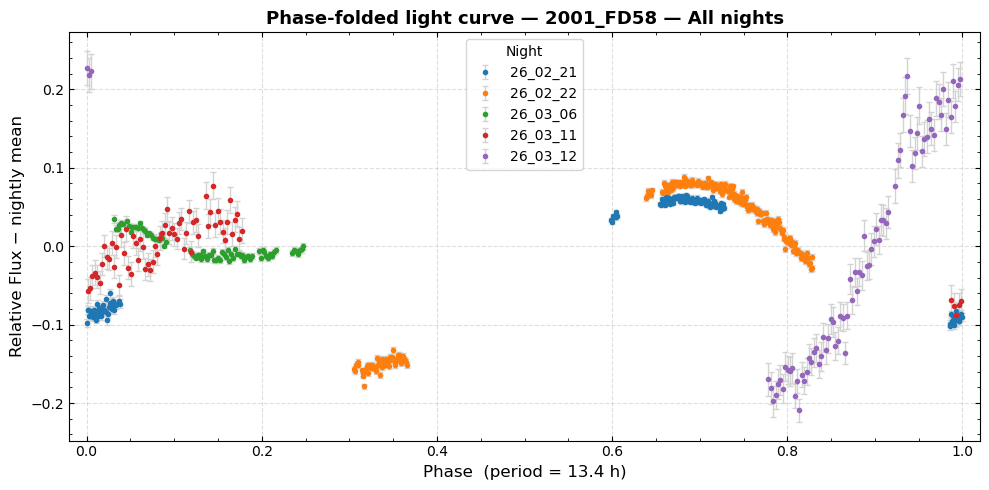

In [7]:
# ── Plot ───────────────────────────────────────────────────────────────────────
T = 13.4

plot_light_curve_all_nights(TARGET, df, night_col="night", period=T, merge_nights=True)